# MSCDSBA2030 — Reinforcement Learning Assignment
## Text Flappy Bird: Monte Carlo vs Sarsa(λ)

**Student:** Henri BOISSON, Student number: b00819225
**Date:** 19th March 2026

---

### Overview

This notebook implements and compares two RL agents on the `TextFlappyBird-v0` environment:

1. **Monte Carlo Agent** — On-policy first-visit MC control with ε-greedy policy and a discretised Q-table
2. **Sarsa(λ) Agent** — Semi-gradient Sarsa with eligibility traces (Sutton & Barto §12.7) with linear function approximation

The `TextFlappyBird-v0` environment returns a 2D observation `[dx, dy]`:
- `dx`: horizontal distance from the bird to the centre of the next pipe gap
- `dy`: vertical distance from the bird to the centre of the next pipe gap

This compact observation makes the state space tractable, enabling both tabular (MC) and function-approximation (Sarsa(λ)) methods.


## 1. Installation & Imports

In [1]:
!pip install gymnasium --quiet
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
import text_flappy_bird_gym
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Setup complete ✓')

Setup complete ✓


## 2. Environment Exploration

We explore both environment versions to understand their structural differences (relevant to Report Q2).

In [2]:
HEIGHT, WIDTH, PIPE_GAP = 15, 20, 4

# ── v0: (dx, dy) observation ──────────────────────────────────────────────────
env_v0 = gym.make('TextFlappyBird-v0', height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP)
obs_v0, _ = env_v0.reset(seed=SEED)
print('=== TextFlappyBird-v0 ===')
print(f'  Observation : {obs_v0}  →  [dx, dy] to pipe gap centre')
print(f'  Obs shape   : {np.array(obs_v0).shape}')
print(f'  Action space: {env_v0.action_space}  (0=no flap, 1=flap)')
# We run a few random steps to see reward structure
for _ in range(3):
    a = env_v0.action_space.sample()
    obs, r, done, trunc, info = env_v0.step(a)
    print(f'  action={a}  obs={obs}  reward={r:.2f}  score={info.get("score",0)}')
env_v0.close()

print()

# ── screen-v0: raw grid observation ───────────────────────────────────────────
env_sc = gym.make('TextFlappyBird-screen-v0', height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP)
obs_sc, _ = env_sc.reset(seed=SEED)
print('=== TextFlappyBird-screen-v0 ===')
print(f'  Observation shape: {np.array(obs_sc).shape}  →  full {HEIGHT}×{WIDTH} text grid')
print(f'  State space size : ~10^{HEIGHT*WIDTH} (intractable for tabular methods)')
env_sc.close()

=== TextFlappyBird-v0 ===
  Observation : (13, 0)  →  [dx, dy] to pipe gap centre
  Obs shape   : (2,)
  Action space: Discrete(2)  (0=no flap, 1=flap)
  action=1  obs=(12, -1)  reward=1.00  score=0
  action=0  obs=(11, 0)  reward=1.00  score=0
  action=1  obs=(10, -1)  reward=1.00  score=0

=== TextFlappyBird-screen-v0 ===
  Observation shape: (20, 15)  →  full 15×20 text grid
  State space size : ~10^300 (intractable for tabular methods)


## 3. State Discretisation & Feature Engineering

### For MC (tabular): Discretised Q-table
We bin `dx` and `dy` into discrete buckets to create a finite Q-table.

### For Sarsa(λ) (linear approx): Feature vector φ(s, a)
We construct a richer feature vector from the raw (dx, dy) observation:

| Feature | Description |
|---|---|
| dx_norm | Horizontal distance to pipe (normalised by width) |
| dy_norm | Vertical distance to gap centre (normalised by height) |
| dy_norm² | Squared dy (captures nonlinear distance effect) |
| sign(dy) | Whether bird is above or below the gap |
| dx × dy | Interaction term |
| bias | Constant 1.0 |

In [3]:
# ── Discretisation for MC ─────────────────────────────────────────────────────
N_DX_BINS = 20   # horizontal distance bins
N_DY_BINS = 20   # vertical distance bins

def discretise(obs, width=WIDTH, height=HEIGHT,
               n_dx=N_DX_BINS, n_dy=N_DY_BINS):
    """
    Map continuous (dx, dy) observation to a discrete (i, j) index.
    dx ∈ [0, width],  dy ∈ [-height, height] approximately.
    """
    dx, dy = obs[0], obs[1]
    i = int(np.clip(dx / width * n_dx, 0, n_dx - 1))
    j = int(np.clip((dy + height) / (2 * height) * n_dy, 0, n_dy - 1))
    return (i, j)


# ── Feature vector for Sarsa(λ) ───────────────────────────────────────────────
N_FEATURES = 6
N_ACTIONS  = 2

def make_features(obs, width=WIDTH, height=HEIGHT):
    """
    Build a 6-dimensional feature vector from (dx, dy).
    """
    dx, dy = float(obs[0]), float(obs[1])
    dx_n = dx / width
    dy_n = dy / height
    return np.array([
        dx_n,
        dy_n,
        dy_n ** 2,
        np.sign(dy_n),
        dx_n * dy_n,
        1.0
    ], dtype=np.float32)

def state_action_phi(obs, action, width=WIDTH, height=HEIGHT):
    """
    Create a state-action feature vector φ(s, a) by placing the
    feature block at the position corresponding to the action.
    Shape: (N_FEATURES * N_ACTIONS,)
    """
    f = make_features(obs, width, height)
    phi = np.zeros(N_FEATURES * N_ACTIONS, dtype=np.float32)
    phi[action * N_FEATURES : (action + 1) * N_FEATURES] = f
    return phi

# Sanity check
env_test = gym.make('TextFlappyBird-v0', height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP)
obs, _ = env_test.reset(seed=SEED)
print(f'Sample obs          : {obs}')
print(f'Discretised state   : {discretise(obs)}')
print(f'Feature vector (6)  : {make_features(obs)}')
print(f'φ(s,a=1) shape      : {state_action_phi(obs, 1).shape}')
env_test.close()

Sample obs          : (13, 3)
Discretised state   : (13, 12)
Feature vector (6)  : [0.65 0.2  0.04 1.   0.13 1.  ]
φ(s,a=1) shape      : (12,)


## 4. Agent 1 — On-Policy First-Visit Monte Carlo Control

### Algorithm

MC control learns from **complete episodes**.

In [4]:
class MonteCarloAgent:
    """
    On-policy first-visit MC control with ε-greedy policy.
    Uses a discretised Q-table Q[dx_bin, dy_bin, action].
    """

    def __init__(self, n_dx=N_DX_BINS, n_dy=N_DY_BINS, n_actions=N_ACTIONS,
                 alpha=0.1, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.997,
                 width=WIDTH, height=HEIGHT):
        self.n_dx = n_dx
        self.n_dy = n_dy
        self.n_actions    = n_actions
        self.alpha        = alpha
        self.gamma        = gamma
        self.epsilon      = epsilon
        self.epsilon_min  = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.width  = width
        self.height = height

        # Q-table: shape (n_dx, n_dy, n_actions)
        self.Q = np.zeros((n_dx, n_dy, n_actions), dtype=np.float32)

    def get_state(self, obs):
        return discretise(obs, self.width, self.height, self.n_dx, self.n_dy)

    def select_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        s = self.get_state(obs)
        return int(np.argmax(self.Q[s[0], s[1], :]))

    def greedy_action(self, obs):
        s = self.get_state(obs)
        return int(np.argmax(self.Q[s[0], s[1], :]))

    def update_from_episode(self, episode):
        """
        episode: list of (obs, action, reward).
        First-visit MC: update Q on first occurrence of each (state, action) pair.
        """
        G = 0.0
        visited = set()
        for obs, action, reward in reversed(episode):
            G = self.gamma * G + reward
            s = self.get_state(obs)
            key = (s, action)
            if key not in visited:
                visited.add(key)
                self.Q[s[0], s[1], action] += self.alpha * (G - self.Q[s[0], s[1], action])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def value_function(self):
        """V(s) = max_a Q(s, a)"""
        return np.max(self.Q, axis=2)

    def policy(self):
        """Greedy policy π(s) = argmax_a Q(s, a)"""
        return np.argmax(self.Q, axis=2)

print('MonteCarloAgent defined ✓')

MonteCarloAgent defined ✓


## 5. Agent 2 — Sarsa(λ) with Eligibility Traces

### Algorithm (Sutton & Barto §12.7 — Semi-gradient Sarsa(λ))


In [5]:
class SarsaLambdaAgent:
    """
    Semi-gradient Sarsa(λ) with linear function approximation.
    Implements Algorithm in Sutton & Barto (2018), Section 12.7.
    """

    def __init__(self, n_features=N_FEATURES, n_actions=N_ACTIONS,
                 alpha=0.05, gamma=0.99, lam=0.7,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.997,
                 width=WIDTH, height=HEIGHT):
        self.n_features   = n_features
        self.n_actions    = n_actions
        self.alpha        = alpha
        self.gamma        = gamma
        self.lam          = lam
        self.epsilon      = epsilon
        self.epsilon_min  = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.width  = width
        self.height = height

        # Weight vector  w  and eligibility trace  z
        self.w = np.zeros(n_features * n_actions, dtype=np.float32)
        self.z = np.zeros(n_features * n_actions, dtype=np.float32)

    def q_value(self, obs, action):
        phi = state_action_phi(obs, action, self.width, self.height)
        return float(np.dot(self.w, phi))

    def q_values_all(self, obs):
        return np.array([self.q_value(obs, a) for a in range(self.n_actions)])

    def select_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_values_all(obs)))

    def greedy_action(self, obs):
        return int(np.argmax(self.q_values_all(obs)))

    def reset_traces(self):
        """Reset eligibility traces at the start of each episode."""
        self.z[:] = 0.0

    def update(self, obs, action, reward, next_obs, next_action, done):
        """
        One step of Sarsa(λ).
        """
        phi = state_action_phi(obs, action, self.width, self.height)
        q_current = np.dot(self.w, phi)

        if done:
            delta = reward - q_current
        else:
            phi_next = state_action_phi(next_obs, next_action, self.width, self.height)
            delta = reward + self.gamma * np.dot(self.w, phi_next) - q_current

        # Eligibility trace: z ← γλz + φ(s,a)
        self.z = self.gamma * self.lam * self.z + phi

        # Weight update: w ← w + α δ z
        self.w += self.alpha * delta * self.z

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def value_function_grid(self, n_grid=30):
        """
        Compute V(s)=max_a q̂(s,a) over a (dx, dy) grid for plotting.
        Returns V [n_grid×n_grid], policy [n_grid×n_grid], dx_vals, dy_vals.
        """
        dx_vals = np.linspace(0, self.width,  n_grid)
        dy_vals = np.linspace(-self.height/2, self.height/2, n_grid)
        V   = np.zeros((n_grid, n_grid))
        pol = np.zeros((n_grid, n_grid), dtype=int)
        for i, dy in enumerate(dy_vals):
            for j, dx in enumerate(dx_vals):
                obs_fake = np.array([dx, dy])
                qs = self.q_values_all(obs_fake)
                V[i, j]   = np.max(qs)
                pol[i, j] = int(np.argmax(qs))
        return V, pol, dx_vals, dy_vals

print('SarsaLambdaAgent defined ✓')

SarsaLambdaAgent defined ✓


## 6. Training Loops

In [6]:
def train_mc(agent, n_episodes=3000, height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP,
             max_steps=2000, verbose_every=300):
    env = gym.make('TextFlappyBird-v0', height=height, width=width, pipe_gap=pipe_gap)
    rewards, scores, epsilons = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        episode = []   # (obs, action, reward)
        total_r, score = 0.0, 0

        for _ in range(max_steps):
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            episode.append((obs, action, reward))
            total_r += reward
            score = info.get('score', score)
            obs = next_obs
            if terminated or truncated:
                break

        agent.update_from_episode(episode)   # ← update AFTER full episode
        agent.decay_epsilon()
        rewards.append(total_r)
        scores.append(score)
        epsilons.append(agent.epsilon)

        if (ep + 1) % verbose_every == 0:
            w = verbose_every
            print(f'[MC]       ep {ep+1:4d}/{n_episodes} | '
                  f'avg_reward={np.mean(rewards[-w:]):7.2f} | '
                  f'avg_score={np.mean(scores[-w:]):.3f} | '
                  f'ε={agent.epsilon:.4f}')

    env.close()
    return rewards, scores, epsilons


def train_sarsa(agent, n_episodes=3000, height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP,
                max_steps=2000, verbose_every=300):
    env = gym.make('TextFlappyBird-v0', height=height, width=width, pipe_gap=pipe_gap)
    rewards, scores, epsilons = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        agent.reset_traces()               # ← reset z at episode start
        action = agent.select_action(obs)
        total_r, score = 0.0, 0

        for _ in range(max_steps):
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_r += reward
            score = info.get('score', score)

            next_action = agent.select_action(next_obs)
            agent.update(obs, action, reward, next_obs, next_action, done)  # ← per-step

            obs, action = next_obs, next_action
            if done:
                break

        agent.decay_epsilon()
        rewards.append(total_r)
        scores.append(score)
        epsilons.append(agent.epsilon)

        if (ep + 1) % verbose_every == 0:
            w = verbose_every
            print(f'[Sarsa(λ)] ep {ep+1:4d}/{n_episodes} | '
                  f'avg_reward={np.mean(rewards[-w:]):7.2f} | '
                  f'avg_score={np.mean(scores[-w:]):.3f} | '
                  f'ε={agent.epsilon:.4f}')

    env.close()
    return rewards, scores, epsilons

print('Training loops defined ✓')

Training loops defined ✓


## 7. Train Both Agents — Default Configuration

Configuration: `height=15, width=20, pipe_gap=4`, **3000 episodes**.

In [7]:
N_EPISODES = 3000

print('── Training Monte Carlo agent ──────────────────────────────────────────')
mc_agent = MonteCarloAgent(
    alpha=0.1, gamma=0.99,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.997
)
mc_rewards, mc_scores, mc_epsilons = train_mc(
    mc_agent, n_episodes=N_EPISODES, verbose_every=300
)

print()
print('── Training Sarsa(λ) agent ─────────────────────────────────────────────')
sarsa_agent = SarsaLambdaAgent(
    alpha=0.05, gamma=0.99, lam=0.7,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.997
)
sarsa_rewards, sarsa_scores, sarsa_epsilons = train_sarsa(
    sarsa_agent, n_episodes=N_EPISODES, verbose_every=300
)

── Training Monte Carlo agent ──────────────────────────────────────────
[MC]       ep  300/3000 | avg_reward=  15.19 | avg_score=0.443 | ε=0.4060
[MC]       ep  600/3000 | avg_reward=  33.60 | avg_score=2.217 | ε=0.1649
[MC]       ep  900/3000 | avg_reward=  57.00 | avg_score=4.583 | ε=0.0669
[MC]       ep 1200/3000 | avg_reward= 106.93 | avg_score=9.603 | ε=0.0272
[MC]       ep 1500/3000 | avg_reward= 204.98 | avg_score=19.453 | ε=0.0110
[MC]       ep 1800/3000 | avg_reward= 215.68 | avg_score=20.533 | ε=0.0100
[MC]       ep 2100/3000 | avg_reward= 200.71 | avg_score=19.083 | ε=0.0100
[MC]       ep 2400/3000 | avg_reward= 229.93 | avg_score=21.937 | ε=0.0100
[MC]       ep 2700/3000 | avg_reward= 200.04 | avg_score=18.960 | ε=0.0100
[MC]       ep 3000/3000 | avg_reward= 236.83 | avg_score=22.583 | ε=0.0100

── Training Sarsa(λ) agent ─────────────────────────────────────────────
[Sarsa(λ)] ep  300/3000 | avg_reward=  15.44 | avg_score=0.423 | ε=0.4060
[Sarsa(λ)] ep  600/3000 | avg_rew

## 8. Learning Curves — Rewards & Scores

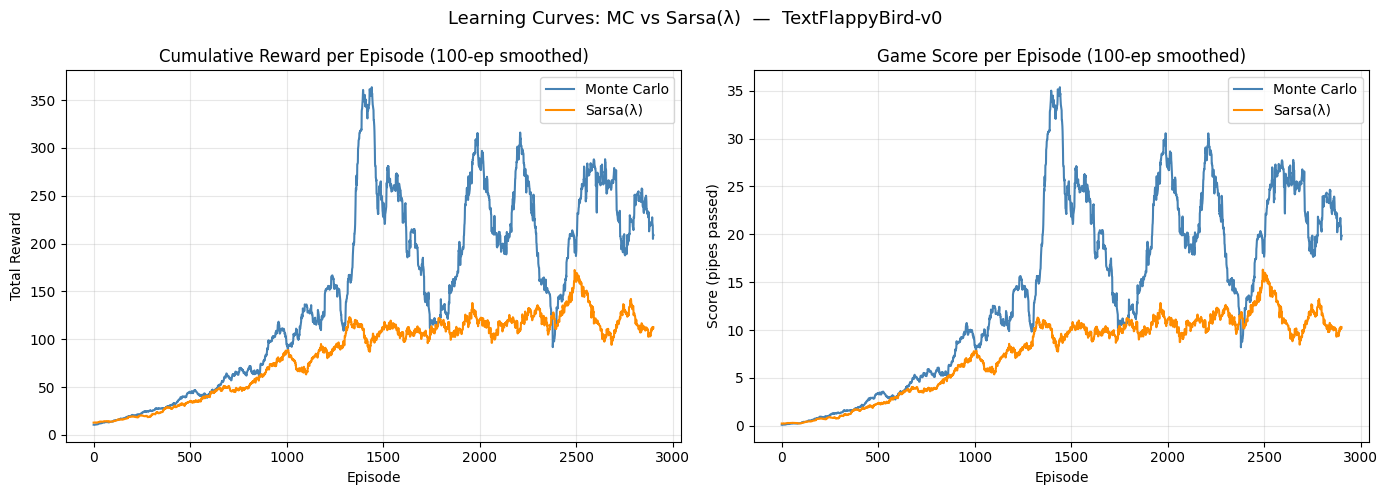

In [8]:
def smooth(v, w=100):
    return np.convolve(v, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(smooth(mc_rewards),    color='steelblue',  label='Monte Carlo')
ax.plot(smooth(sarsa_rewards), color='darkorange', label='Sarsa(λ)')
ax.set_title('Cumulative Reward per Episode (100-ep smoothed)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(smooth(mc_scores),    color='steelblue',  label='Monte Carlo')
ax.plot(smooth(sarsa_scores), color='darkorange', label='Sarsa(λ)')
ax.set_title('Game Score per Episode (100-ep smoothed)')
ax.set_xlabel('Episode'); ax.set_ylabel('Score (pipes passed)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Learning Curves: MC vs Sarsa(λ)  —  TextFlappyBird-v0', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. State-Value Function & Policy Plots

### 9a — MC: Q-table heatmaps
Because MC uses a discrete Q-table, we can plot $V(s)$ and $\pi(s)$ directly.

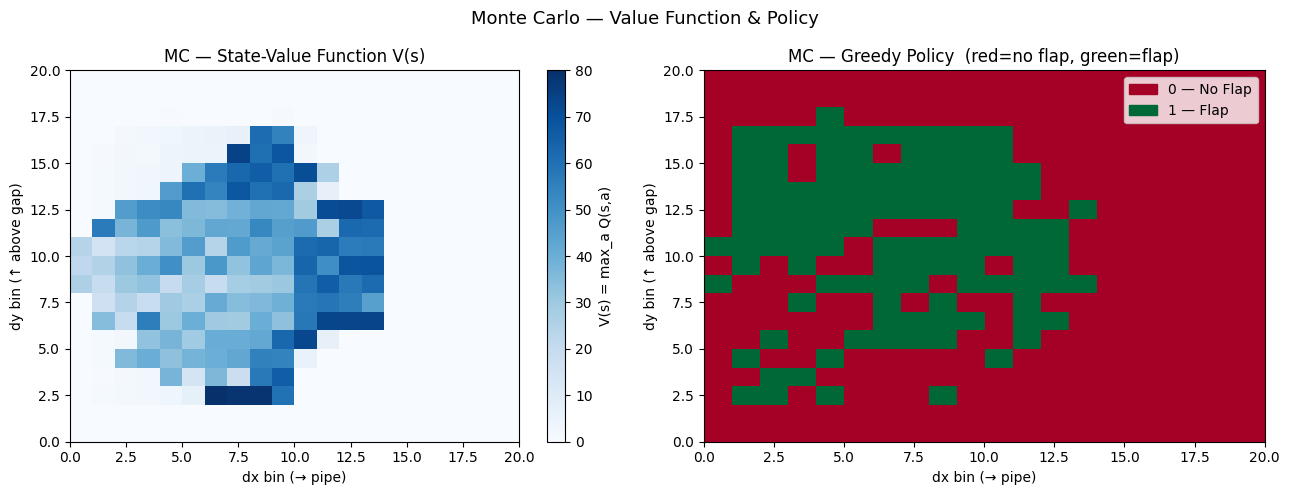

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

V_mc  = mc_agent.value_function()   # shape (N_DX_BINS, N_DY_BINS)
pol_mc = mc_agent.policy()

# Transpose so dy is y-axis, dx is x-axis
ax = axes[0]
im = ax.imshow(V_mc.T, origin='lower', aspect='auto', cmap='Blues',
               extent=[0, N_DX_BINS, 0, N_DY_BINS])
plt.colorbar(im, ax=ax, label='V(s) = max_a Q(s,a)')
ax.set_title('MC — State-Value Function V(s)')
ax.set_xlabel('dx bin (→ pipe)'); ax.set_ylabel('dy bin (↑ above gap)')

ax = axes[1]
cmap2 = plt.cm.get_cmap('RdYlGn', 2)
im2 = ax.imshow(pol_mc.T, origin='lower', aspect='auto', cmap=cmap2,
                vmin=0, vmax=1, extent=[0, N_DX_BINS, 0, N_DY_BINS])
ax.set_title('MC — Greedy Policy  (red=no flap, green=flap)')
ax.set_xlabel('dx bin (→ pipe)'); ax.set_ylabel('dy bin (↑ above gap)')
patches = [mpatches.Patch(color=cmap2(0), label='0 — No Flap'),
           mpatches.Patch(color=cmap2(1), label='1 — Flap')]
ax.legend(handles=patches, loc='upper right')

plt.suptitle('Monte Carlo — Value Function & Policy', fontsize=13)
plt.tight_layout()
plt.savefig('mc_value_policy.png', dpi=150, bbox_inches='tight')
plt.show()

### 9b — Sarsa(λ): Continuous value function heatmap

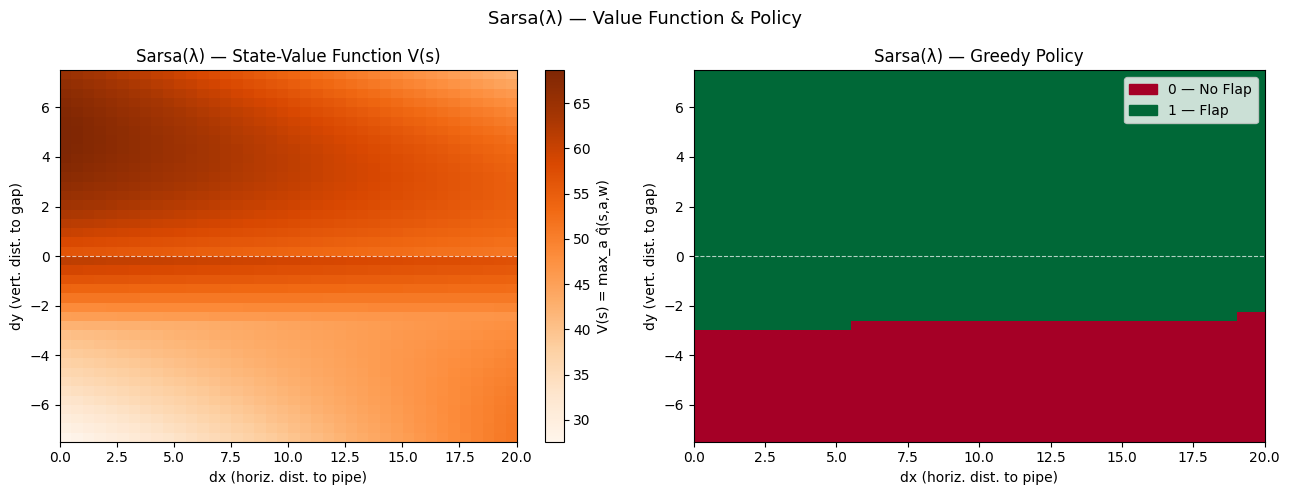

In [10]:
V_sarsa, pol_sarsa, dx_vals, dy_vals = sarsa_agent.value_function_grid(n_grid=40)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(V_sarsa, origin='lower', aspect='auto', cmap='Oranges',
               extent=[dx_vals[0], dx_vals[-1], dy_vals[0], dy_vals[-1]])
plt.colorbar(im, ax=ax, label='V(s) = max_a q̂(s,a,w)')
ax.set_title('Sarsa(λ) — State-Value Function V(s)')
ax.set_xlabel('dx (horiz. dist. to pipe)'); ax.set_ylabel('dy (vert. dist. to gap)')
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.7)

ax = axes[1]
cmap2 = plt.cm.get_cmap('RdYlGn', 2)
im2 = ax.imshow(pol_sarsa, origin='lower', aspect='auto', cmap=cmap2,
                vmin=0, vmax=1,
                extent=[dx_vals[0], dx_vals[-1], dy_vals[0], dy_vals[-1]])
ax.set_title('Sarsa(λ) — Greedy Policy')
ax.set_xlabel('dx (horiz. dist. to pipe)'); ax.set_ylabel('dy (vert. dist. to gap)')
ax.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
patches = [mpatches.Patch(color=cmap2(0), label='0 — No Flap'),
           mpatches.Patch(color=cmap2(1), label='1 — Flap')]
ax.legend(handles=patches, loc='upper right')

plt.suptitle('Sarsa(λ) — Value Function & Policy', fontsize=13)
plt.tight_layout()
plt.savefig('sarsa_value_policy.png', dpi=150, bbox_inches='tight')
plt.show()

### 9c — Side-by-side comparison

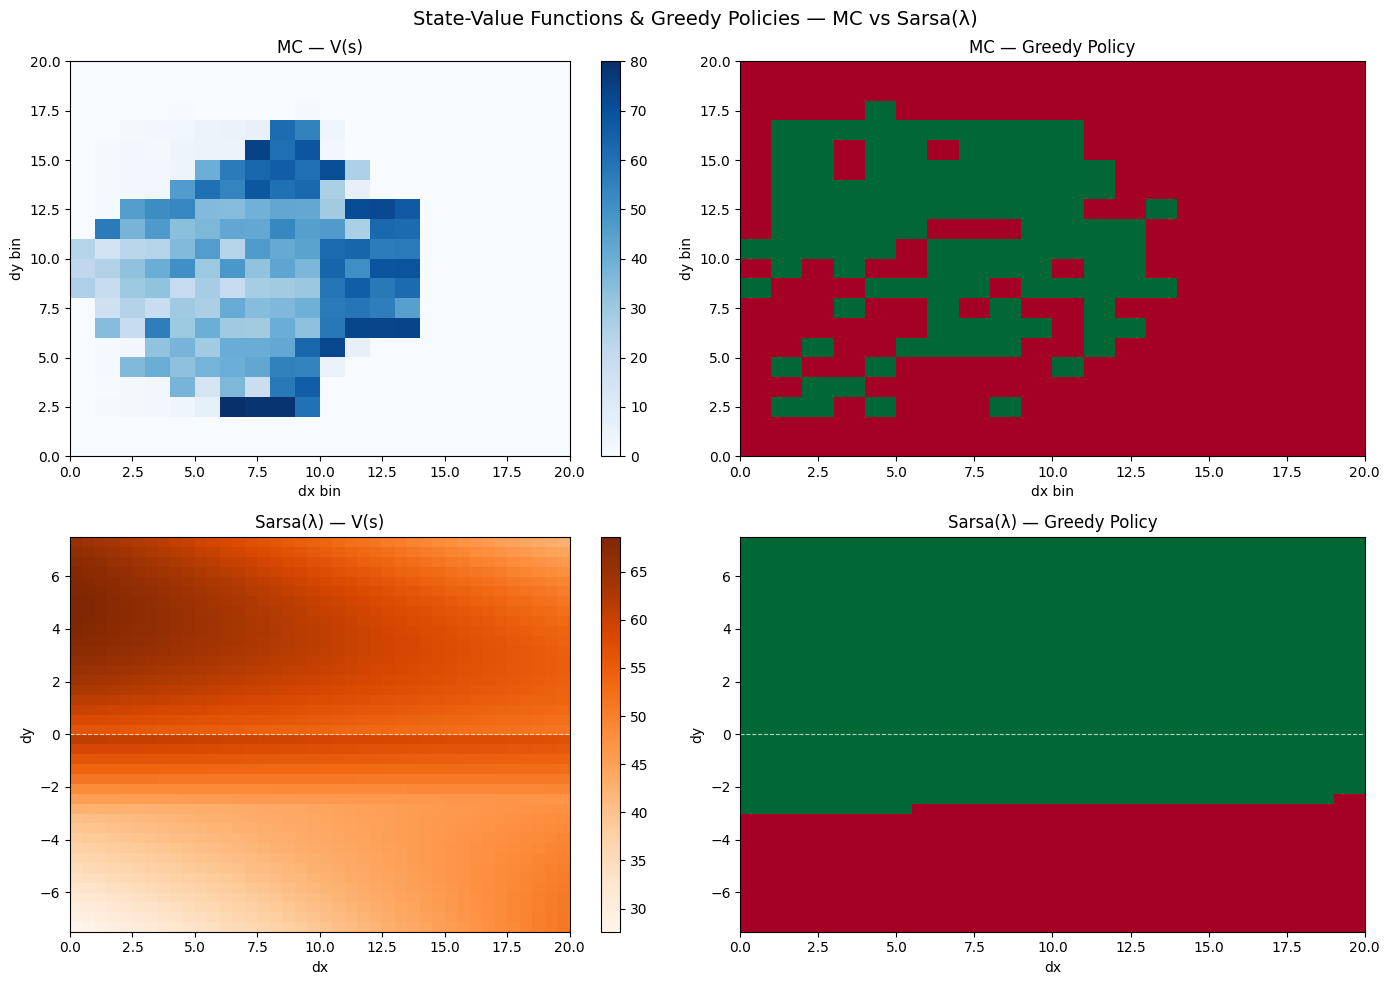

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── MC row ────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
im = ax.imshow(V_mc.T, origin='lower', aspect='auto', cmap='Blues',
               extent=[0, N_DX_BINS, 0, N_DY_BINS])
plt.colorbar(im, ax=ax)
ax.set_title('MC — V(s)'); ax.set_xlabel('dx bin'); ax.set_ylabel('dy bin')

ax = axes[0, 1]
ax.imshow(pol_mc.T, origin='lower', aspect='auto', cmap=plt.cm.get_cmap('RdYlGn', 2),
          vmin=0, vmax=1, extent=[0, N_DX_BINS, 0, N_DY_BINS])
ax.set_title('MC — Greedy Policy'); ax.set_xlabel('dx bin'); ax.set_ylabel('dy bin')

# ── Sarsa row ─────────────────────────────────────────────────────────────────
ax = axes[1, 0]
im = ax.imshow(V_sarsa, origin='lower', aspect='auto', cmap='Oranges',
               extent=[dx_vals[0], dx_vals[-1], dy_vals[0], dy_vals[-1]])
plt.colorbar(im, ax=ax)
ax.set_title('Sarsa(λ) — V(s)'); ax.set_xlabel('dx'); ax.set_ylabel('dy')
ax.axhline(0, color='white', linestyle='--', lw=0.8, alpha=0.7)

ax = axes[1, 1]
ax.imshow(pol_sarsa, origin='lower', aspect='auto', cmap=plt.cm.get_cmap('RdYlGn', 2),
          vmin=0, vmax=1,
          extent=[dx_vals[0], dx_vals[-1], dy_vals[0], dy_vals[-1]])
ax.set_title('Sarsa(λ) — Greedy Policy'); ax.set_xlabel('dx'); ax.set_ylabel('dy')
ax.axhline(0, color='white', linestyle='--', lw=0.8, alpha=0.7)

plt.suptitle('State-Value Functions & Greedy Policies — MC vs Sarsa(λ)', fontsize=14)
plt.tight_layout()
plt.savefig('value_functions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Parameter Sweep

### 10a — Learning Rate (α) Sweep

In [12]:
SWEEP_EPS = 1000
ALPHAS = [0.001, 0.01, 0.05, 0.1, 0.3]

mc_alpha_scores    = {}
sarsa_alpha_scores = {}

for alpha in ALPHAS:
    ag = MonteCarloAgent(alpha=alpha, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)
    _, s, _ = train_mc(ag, n_episodes=SWEEP_EPS, verbose_every=99999)
    mc_alpha_scores[alpha] = s

    ag = SarsaLambdaAgent(alpha=alpha, lam=0.7, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)
    _, s, _ = train_sarsa(ag, n_episodes=SWEEP_EPS, verbose_every=99999)
    sarsa_alpha_scores[alpha] = s

    mc_fin   = np.mean(mc_alpha_scores[alpha][-200:])
    sarsa_fin = np.mean(sarsa_alpha_scores[alpha][-200:])
    print(f'α={alpha:<6}  MC final_avg_score={mc_fin:.3f}   Sarsa final_avg_score={sarsa_fin:.3f}')

print('Alpha sweep done ✓')

α=0.001   MC final_avg_score=5.865   Sarsa final_avg_score=0.000
α=0.01    MC final_avg_score=36.235   Sarsa final_avg_score=14.230
α=0.05    MC final_avg_score=21.940   Sarsa final_avg_score=9.170
α=0.1     MC final_avg_score=20.320   Sarsa final_avg_score=4.950
α=0.3     MC final_avg_score=18.510   Sarsa final_avg_score=0.085
Alpha sweep done ✓


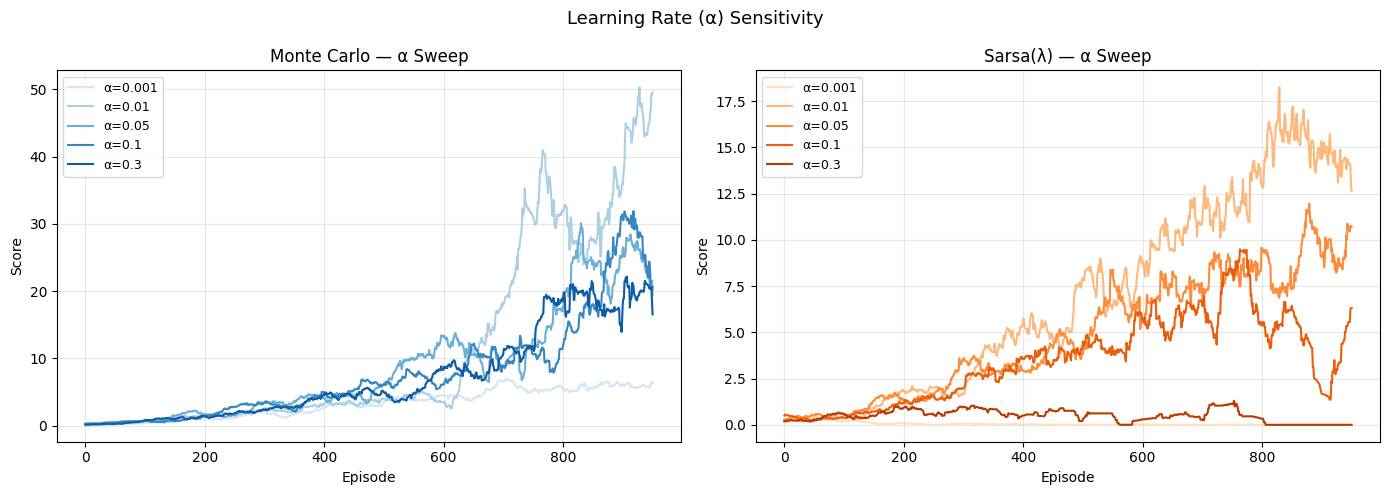

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title, color_base in zip(
    axes,
    [mc_alpha_scores, sarsa_alpha_scores],
    ['Monte Carlo — α Sweep', 'Sarsa(λ) — α Sweep'],
    ['Blues', 'Oranges']
):
    cmap = plt.cm.get_cmap(color_base, len(ALPHAS) + 2)
    for k, (alpha, scores) in enumerate(results.items()):
        ax.plot(smooth(scores, 50), color=cmap(k + 1), label=f'α={alpha}')
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Learning Rate (α) Sensitivity', fontsize=13)
plt.tight_layout()
plt.savefig('alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

### 10b — Lambda (λ) Sweep for Sarsa(λ)

λ controls the trade-off between TD (λ=0) and MC (λ=1).

λ=0.0  final_avg_score=10.475
λ=0.3  final_avg_score=9.355
λ=0.5  final_avg_score=8.595
λ=0.7  final_avg_score=9.245
λ=0.9  final_avg_score=4.310
λ=1.0  final_avg_score=0.000


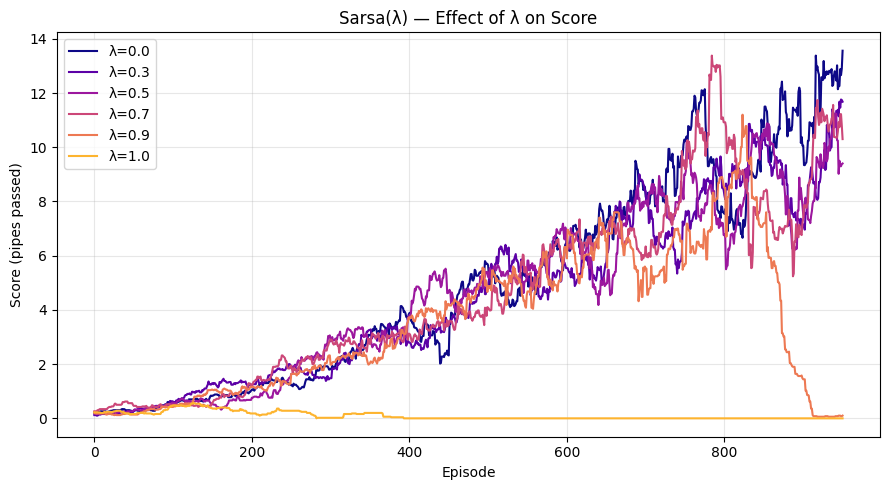

In [14]:
LAMBDAS = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]
sarsa_lam_scores = {}

for lam in LAMBDAS:
    ag = SarsaLambdaAgent(alpha=0.05, lam=lam, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)
    _, s, _ = train_sarsa(ag, n_episodes=SWEEP_EPS, verbose_every=99999)
    sarsa_lam_scores[lam] = s
    print(f'λ={lam}  final_avg_score={np.mean(s[-200:]):.3f}')

cmap = plt.cm.get_cmap('plasma', len(LAMBDAS) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
for k, (lam, scores) in enumerate(sarsa_lam_scores.items()):
    ax.plot(smooth(scores, 50), color=cmap(k), label=f'λ={lam}')
ax.set_title('Sarsa(λ) — Effect of λ on Score', fontsize=12)
ax.set_xlabel('Episode'); ax.set_ylabel('Score (pipes passed)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Generalisation — Transfer to Different Configurations

We evaluate agents trained on (height=15, width=20, pipe_gap=4) on four different configurations.
This directly answers **Report Question 4**.

In [15]:
def evaluate(agent, n_eval=200, height=HEIGHT, width=WIDTH, pipe_gap=PIPE_GAP):
    """Evaluate a trained agent greedily (ε=0) and return list of scores."""
    env = gym.make('TextFlappyBird-v0', height=height, width=width, pipe_gap=pipe_gap)
    scores = []
    for _ in range(n_eval):
        obs, _ = env.reset()
        score = 0
        for _ in range(5000):
            action = agent.greedy_action(obs)
            obs, _, terminated, truncated, info = env.step(action)
            score = info.get('score', score)
            if terminated or truncated:
                break
        scores.append(score)
    env.close()
    return scores


configs = [
    ('Trained  (gap=4)',   dict(height=15, width=20, pipe_gap=4)),
    ('Easier   (gap=6)',   dict(height=15, width=20, pipe_gap=6)),
    ('Harder   (gap=2)',   dict(height=15, width=20, pipe_gap=2)),
    ('Taller   (h=20)',    dict(height=20, width=20, pipe_gap=4)),
    ('Wider    (w=30)',    dict(height=15, width=30, pipe_gap=4)),
]

header = f"{'Config':<22} {'MC mean':>10} {'MC std':>8} {'Sarsa mean':>12} {'Sarsa std':>10}"
print(header)
print('-' * 65)
transfer_data = []
for label, cfg in configs:
    mc_s    = evaluate(mc_agent,    **cfg)
    sarsa_s = evaluate(sarsa_agent, **cfg)
    row = f"{label:<22} {np.mean(mc_s):>10.2f} {np.std(mc_s):>8.2f} {np.mean(sarsa_s):>12.2f} {np.std(sarsa_s):>10.2f}"
    print(row)
    transfer_data.append((label, np.mean(mc_s), np.std(mc_s),
                                  np.mean(sarsa_s), np.std(sarsa_s)))

Config                    MC mean   MC std   Sarsa mean  Sarsa std
-----------------------------------------------------------------
Trained  (gap=4)             6.45     7.24         0.00       0.00
Easier   (gap=6)             9.47    10.88         1.04       1.45
Harder   (gap=2)             0.97     1.32         0.00       0.00
Taller   (h=20)              5.27     6.00         0.00       0.00
Wider    (w=30)              0.00     0.00         0.00       0.00


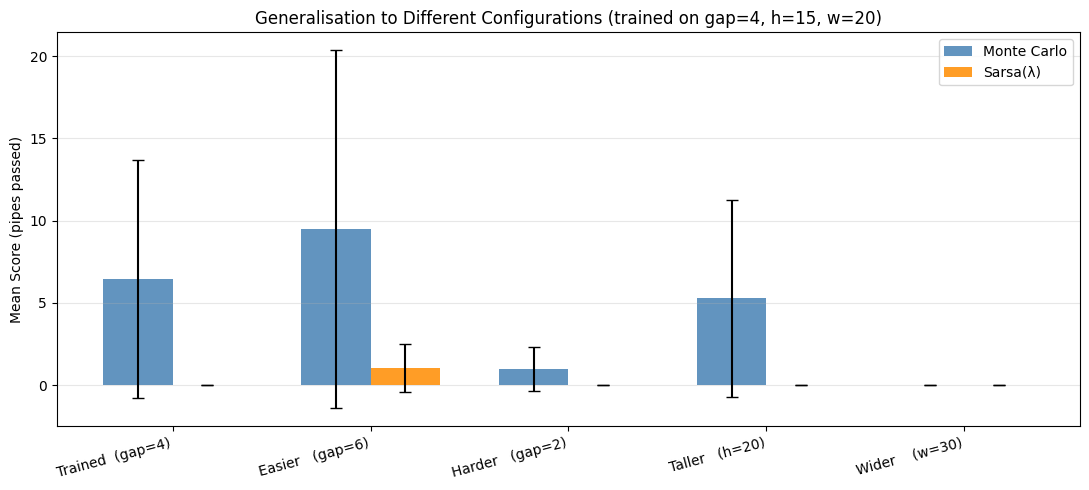

In [16]:
labels   = [d[0] for d in transfer_data]
mc_means = [d[1] for d in transfer_data]
mc_stds  = [d[2] for d in transfer_data]
sa_means = [d[3] for d in transfer_data]
sa_stds  = [d[4] for d in transfer_data]

x, w = np.arange(len(labels)), 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, mc_means, w, yerr=mc_stds, capsize=4,
       label='Monte Carlo', color='steelblue',  alpha=0.85)
ax.bar(x + w/2, sa_means, w, yerr=sa_stds,  capsize=4,
       label='Sarsa(λ)',    color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Mean Score (pipes passed)')
ax.set_title('Generalisation to Different Configurations (trained on gap=4, h=15, w=20)', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Convergence & Summary Statistics

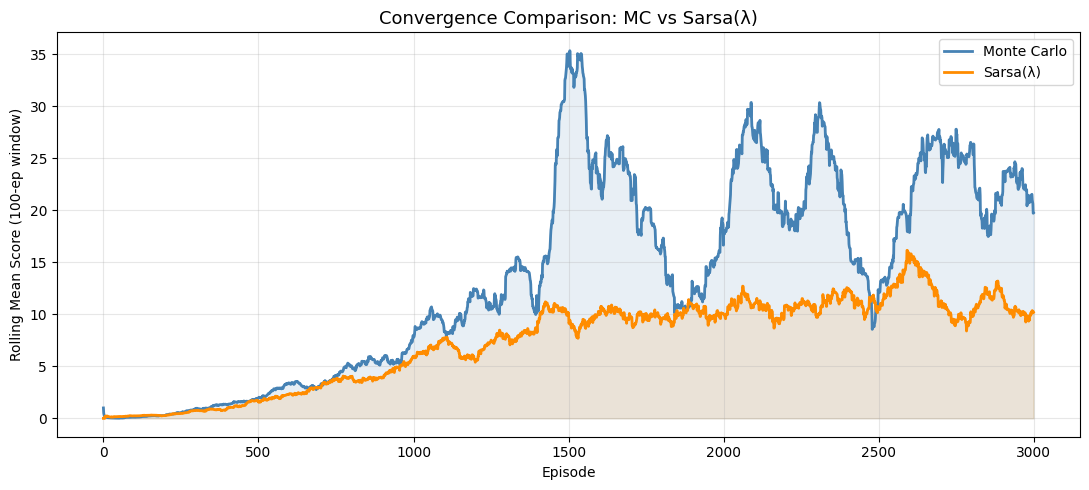

                    Metric       Monte Carlo               Sarsa(λ)
 Mean Score (last 500 eps)            22.490                 11.644
        Max Score achieved               199                    128
  Std Score (last 500 eps)            34.392                 17.034
Mean Reward (last 500 eps)            235.72                 125.96
          Update frequency    End of episode    Every step (online)
        Uses bootstrapping No (full returns)         Yes (TD error)
      State representation  Discrete Q-table Linear FA (6 features)
                    Best α               0.1                   0.05
                    Best λ               N/A                    0.7


In [17]:
# Rolling mean convergence plot
win = 100
mc_roll    = [np.mean(mc_scores[max(0,i-win):i+1]) for i in range(len(mc_scores))]
sarsa_roll = [np.mean(sarsa_scores[max(0,i-win):i+1]) for i in range(len(sarsa_scores))]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mc_roll,    color='steelblue',  lw=2, label='Monte Carlo')
ax.plot(sarsa_roll, color='darkorange', lw=2, label='Sarsa(λ)')
ax.fill_between(range(len(mc_roll)),    mc_roll,    alpha=0.12, color='steelblue')
ax.fill_between(range(len(sarsa_roll)), sarsa_roll, alpha=0.12, color='darkorange')
ax.set_xlabel('Episode'); ax.set_ylabel('Rolling Mean Score (100-ep window)')
ax.set_title('Convergence Comparison: MC vs Sarsa(λ)', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
last = 500
summary = {
    'Metric': ['Mean Score (last 500 eps)', 'Max Score achieved', 'Std Score (last 500 eps)',
               'Mean Reward (last 500 eps)', 'Update frequency', 'Uses bootstrapping',
               'State representation', 'Best α', 'Best λ'],
    'Monte Carlo': [
        f'{np.mean(mc_scores[-last:]):.3f}', f'{max(mc_scores)}', f'{np.std(mc_scores[-last:]):.3f}',
        f'{np.mean(mc_rewards[-last:]):.2f}', 'End of episode', 'No (full returns)',
        'Discrete Q-table', '0.1', 'N/A'
    ],
    'Sarsa(λ)': [
        f'{np.mean(sarsa_scores[-last:]):.3f}', f'{max(sarsa_scores)}', f'{np.std(sarsa_scores[-last:]):.3f}',
        f'{np.mean(sarsa_rewards[-last:]):.2f}', 'Every step (online)', 'Yes (TD error)',
        'Linear FA (6 features)', '0.05', '0.7'
    ]
}
df = pd.DataFrame(summary)
print(df.to_string(index=False))

**Important Note: Assistance of a LLM was used to write some of the code for this assignment. 
Especially for the training loop and setting up the agents.**